# 🌊 FloodGraph Notebook

An end-to-end pipeline that predicts district-level flood risk in India using a Graph Convolutional Network (GCN), then serves the results in an interactive Streamlit dashboard.

```
Your Flood Notebook
       ↓
Historical India Flood Data
       ↓
District-level features
       ↓
Graph Construction
       ↓
GCN Model
       ↓
Flood Probability
       ↓
Risk Level
       ↓
flood_risk_predictions.csv
       ↓
Streamlit app.py
       ↓
Dashboard
```


## Step 1: Setup — Install Libraries

Core data-science and graph deep-learning libraries used by the pipeline.

In [1]:
# Core data & ML libraries
!python -m pip install -q pandas numpy matplotlib seaborn scikit-learn scipy

# Deep learning + Graph Neural Network
!python -m pip install -q torch torchvision torchaudio
!python -m pip install -q torch-geometric



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Imports

In [2]:
import os
import sys
import copy
import warnings
from itertools import combinations

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

print("Libraries imported successfully.")
print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("Torch  :", torch.__version__)


Libraries imported successfully.
Python: 3.13.5
Pandas: 2.3.3
Torch  : 2.7.1+cpu


## Step 3: Historical India Flood Data

Load the raw flood inventory CSV. Place your copy at `data/India_Flood_Inventory_v3.csv`
relative to this notebook (create a `data/` folder next to the notebook if it
doesn't exist yet). Using a relative path keeps the notebook reproducible for
anyone who clones the repo — no more hardcoded personal folders.

In [3]:
FILE_PATH = "data/India_Flood_Inventory_v3.csv"

flood_df = pd.read_csv(FILE_PATH)

print("Flood inventory loaded:", flood_df.shape[0], "rows,", flood_df.shape[1], "columns")
flood_df.head()

Flood inventory loaded: 6876 rows, 23 columns


,Unnamed: 0,UEI,Start Date,End Date,Duration(Days),Main Cause,Location,Districts,State,Latitude,...,Human fatality,Human injured,Human Displaced,Animal Fatality,Description of Casualties/injured,Extent of damage,Event Source,Event Souce ID,District_LGD_Codes,State_Codes
0,563,UEI-IMD-FL-1967-0001,02-07-1967 00:00,08-07-1967 00:00,7.0,flood,NaN,NaN,Assam,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,18
1,564,UEI-IMD-FL-1967-0002,22-07-1967 00:00,28-07-1967 00:00,7.0,flood,NaN,NaN,"Maharashtra, Gujarat",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,"27,24"
2,565,UEI-IMD-FL-1967-0003,01-08-1967 00:00,30-08-1967 00:00,30.0,flood,NaN,NaN,Uttar Pradesh,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,9
3,566,UEI-IMD-FL-1967-0004,08-09-1967 00:00,09-09-1967 00:00,2.0,flood,NaN,"Bhadrak, Dhenkanal, Jajapur, Subarnapur, Nuapa...","Odisha, Bihar, Uttar Pradesh, Madhya Pradesh, ...",NaN,...,NaN,NaN,NaN,NaN,NaN,Marooning of Barwer Express,IMD,NaN,"348, 352, 356, None, 368, 345, 349, 350, 359, ...","21,10,9,23,8,6"
4,567,UEI-IMD-FL-1968-0001,22-06-1968 00:00,28-06-1968 00:00,7.0,flood,NaN,NaN,Assam,NaN,...,NaN,NaN,NaN,NaN,NaN,"Affecting about one million people,an area of ...",IMD,NaN,NaN,18


## Step 4: District-Level Features

Turn raw flood events into per-district features:
1. Parse dates → flood year
2. Explode multi-district events into one row per district (and clean out junk entries)
3. Build **time-safe** historical flood memory (only using data before the target year, to avoid leakage)
4. Create the 2023 flood target label
5. Assemble the final node feature table (one row per district = one graph node)

In [4]:
# --- Parse dates & flood year ---
flood_df["Start Date"] = pd.to_datetime(flood_df["Start Date"], errors="coerce")
flood_df["End Date"] = pd.to_datetime(flood_df["End Date"], errors="coerce")
flood_df["Flood_Year"] = flood_df["Start Date"].dt.year

print("Flood years range from", int(flood_df["Flood_Year"].min()), "to", int(flood_df["Flood_Year"].max()))


Flood years range from 1967 to 2023


### 4a. Sanity check: required columns exist

Cheap insurance against the #1 notebook footgun -- running cells out of
order (or restarting the kernel and only running some cells) after
editing something above. This fails loudly right here with a clear
message instead of a confusing `KeyError` three cells later.

In [5]:
# --- Sanity check before continuing: make sure the columns this
# pipeline depends on actually exist. If this fails, it almost always
# means cells were run out of order -- use "Restart Kernel and Run All"
# and run every cell top to bottom, don't skip around.

required_cols = ["Start Date", "End Date", "Flood_Year", "Districts"]
missing_cols = [c for c in required_cols if c not in flood_df.columns]

assert not missing_cols, (
    f"Missing column(s) {missing_cols} in flood_df.\n"
    "Likely cause: cells were run out of order, or the kernel was "
    "restarted and the 'Parse dates & flood year' cell above wasn't "
    "re-run.\n"
    "Fix: Kernel -> Restart Kernel and Run All Cells, then run every "
    "cell top to bottom without skipping any.\n"
    f"Columns currently in flood_df: {list(flood_df.columns)}"
)

print("All required columns present:", required_cols)

All required columns present: ['Start Date', 'End Date', 'Flood_Year', 'Districts']


In [6]:
# --- Explode events into one row per district, then clean district names ---
event_df = flood_df.copy()
event_df["Event_ID"] = np.arange(len(event_df))
event_df = event_df[event_df["Districts"].notna()].copy()

event_df["District"] = event_df["Districts"].astype(str).str.split(",")
event_df = event_df.explode("District")

event_df["District"] = (
    event_df["District"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"\*$", "", regex=True)
    .str.strip()
)

# Remove broad, non-specific descriptions that are not real district names
invalid_patterns = [
    "districts affected", "districts of", "out of",
    "various parts", "& parts", "parts of",
    "few districts", "most of the districts", "several other district",
]

invalid_mask = event_df["District"].str.lower().apply(
    lambda x: any(p in x for p in invalid_patterns)
)
event_df = event_df[~invalid_mask]

event_df = event_df[
    ~event_df["District"].str.match(r"^\d+\s*(out of\s*)?\d*\s*districts?$", case=False, na=False)
]
event_df = event_df[
    (event_df["District"] != "") & (event_df["District"].str.lower() != "nan")
]

event_df = event_df.drop_duplicates(subset=["Event_ID", "District"]).reset_index(drop=True)

print("District-event records:", len(event_df))
print("Unique districts     :", event_df["District"].nunique())


District-event records: 24274
Unique districts     : 837


### 4b. Clean up near-duplicate district names

The raw inventory has typo/OCR-style variants of the same district
(e.g. `Bagalkotee` vs `Bagalkote`, `Beedar` vs `Bidar`,
`Uttar Kashia Kannada` vs `Uttara Kannada`). Left as-is, these get
treated as separate graph nodes and quietly inflate the district count.

This step does two passes:
1. **Manual aliases** for corrections we already know about.
2. **Fuzzy clustering** (`difflib`) to catch remaining near-duplicates
   automatically, using the most frequent spelling in the data as the
   canonical name for each cluster.

This is a practical, dependency-free fix — not a substitute for
cross-referencing an official government district gazetteer, which
would be the more rigorous approach if you extend this project.

In [7]:
# --- Normalize near-duplicate district names (typos / OCR-style variants) ---
import difflib

# Known corrections we can pin down directly -- extend this as you spot more
MANUAL_ALIASES = {
    "bagalkotee": "Bagalkote",
    "beedar": "Bidar",
    "uttar kashia kannada": "Uttara Kannada",
    "utar kannada": "Uttara Kannada",
}

raw_names = sorted(event_df["District"].dropna().unique())
print("District names before cleanup:", len(raw_names))


def normalize_key(name):
    return name.strip().lower()


def apply_manual(name):
    return MANUAL_ALIASES.get(normalize_key(name), name)


partially_cleaned = [apply_manual(n) for n in raw_names]

# Fuzzy-cluster whatever's left: group names that are near-identical
# (catches variants the manual alias list above doesn't cover)
unmatched = sorted(set(partially_cleaned))
canonical_map = {}
used = set()

for name in unmatched:
    if name in used:
        continue
    close = difflib.get_close_matches(
        name, [n for n in unmatched if n not in used], n=10, cutoff=0.88
    )
    cluster = set(close) | {name}
    counts = {c: partially_cleaned.count(c) for c in cluster}
    # Canonical spelling = most frequent in the data, tie-break on shortest
    canonical = max(counts, key=lambda c: (counts[c], -len(c)))
    for c in cluster:
        canonical_map[c] = canonical
        used.add(c)


def full_normalize(name):
    return canonical_map.get(apply_manual(name), apply_manual(name))


event_df["District"] = event_df["District"].apply(full_normalize)

print("District names after cleanup :", event_df["District"].nunique())

merge_examples = {k: v for k, v in canonical_map.items() if k != v}
print(f"\nFuzzy merges found: {len(merge_examples)} (review these -- cutoff=0.88 can still miss or over-merge)")
for k, v in list(merge_examples.items())[:15]:
    print(f"  {k!r} -> {v!r}")

District names before cleanup: 837
District names after cleanup : 812

Fuzzy merges found: 24 (review these -- cutoff=0.88 can still miss or over-merge)
  'Ananthapuramuamu' -> 'Ananthapuramu'
  'Baleshwar' -> 'Bageshwar'
  'Chamarajanagaraa' -> 'Chamarajanagara'
  'Darjeelingm' -> 'Darjeeling'
  'East East Jaintia Hills' -> 'West East Jaintia Hills'
  'Garhwal' -> 'Garhwa'
  'Ghazipurr' -> 'Ghazipur'
  'Gondia' -> 'Gonda'
  'Jaloree' -> 'Jalore'
  'Jhunjhunun' -> 'Jhunjhunu'
  'Kanpur Nagar' -> 'Kanpur nagar'
  'Kanpur nagar-Dehat' -> 'Kanpur nagar Dehat'
  'Kashmir valley' -> 'Kashmir Valley'
  'Maldah' -> 'Malda'
  'Most Upper Lower Subansiri' -> 'Upper Lower Subansiri'


In [8]:
# --- Time-safe historical flood memory (features only use data BEFORE the target year) ---
TARGET_YEAR = 2023
RECENT_START = TARGET_YEAR - 5

past_events = event_df[event_df["Flood_Year"] < TARGET_YEAR].copy()

past_count = past_events.groupby("District").size().rename("Historical_Flood_Count")

recent_past_count = (
    past_events[past_events["Flood_Year"] >= RECENT_START]
    .groupby("District").size().rename("Recent_Flood_Count")
)

last_past_flood = (
    past_events.dropna(subset=["Flood_Year"])
    .groupby("District")["Flood_Year"].max().rename("Last_Flood_Year")
)

historical_memory_safe = pd.concat(
    [past_count, recent_past_count, last_past_flood], axis=1
).fillna(0)

historical_memory_safe["Years_Since_Last_Flood"] = (
    TARGET_YEAR - historical_memory_safe["Last_Flood_Year"]
)

for col in ["Historical_Flood_Count", "Recent_Flood_Count", "Last_Flood_Year", "Years_Since_Last_Flood"]:
    historical_memory_safe[col] = historical_memory_safe[col].astype(int)

historical_memory_safe = historical_memory_safe.reset_index()

print("Districts with historical data:", len(historical_memory_safe))
historical_memory_safe.sort_values("Historical_Flood_Count", ascending=False).head()


Districts with historical data: 756


,District,Historical_Flood_Count,Recent_Flood_Count,Last_Flood_Year,Years_Since_Last_Flood
685,Thiruvananthapuram,115,29,2022,1
387,Lakhimpur,93,21,2022,1
176,Dhemaji,90,23,2022,1
465,Nagpur,83,25,2022,1
460,Nagaon,80,32,2022,1


In [9]:
# --- Flood target: did the district flood in the target year? ---
flood_2023 = set(
    event_df.loc[event_df["Flood_Year"] == TARGET_YEAR, "District"].dropna().unique()
)

all_districts = sorted(event_df["District"].unique())
target_df = pd.DataFrame({"District": all_districts})
target_df["Flood_2023"] = target_df["District"].isin(flood_2023).astype(int)

print(f"Districts flooded in {TARGET_YEAR}: {target_df['Flood_2023'].sum()} / {len(target_df)}")


Districts flooded in 2023: 177 / 812


In [10]:
# --- Final node feature table (one row per district = one graph node) ---
node_df = target_df.merge(historical_memory_safe, on="District", how="left")

memory_columns = ["Historical_Flood_Count", "Recent_Flood_Count", "Last_Flood_Year", "Years_Since_Last_Flood"]
node_df[memory_columns] = node_df[memory_columns].fillna(0)

node_df = node_df.sort_values("District").reset_index(drop=True)
node_df["Node_ID"] = np.arange(len(node_df))

node_df = node_df[[
    "Node_ID", "District", "Historical_Flood_Count", "Recent_Flood_Count",
    "Last_Flood_Year", "Years_Since_Last_Flood", "Flood_2023"
]]

print("Total districts (graph nodes):", len(node_df))
node_df.head()


Total districts (graph nodes): 812


,Node_ID,District,Historical_Flood_Count,Recent_Flood_Count,Last_Flood_Year,Years_Since_Last_Flood,Flood_2023
0,0,Adilabad,17.0,1.0,2022.0,1.0,0
1,1,Agar-Malwa,3.0,0.0,1973.0,50.0,0
2,2,Agra,20.0,3.0,2018.0,5.0,0
3,3,Ahmedabad,28.0,4.0,2022.0,1.0,0
4,4,Ahmednagar,18.0,5.0,2022.0,1.0,1


## Step 5: Graph Construction

Connect two districts with an edge whenever they appeared together in the same historical flood event. This gives the GCN a way to share information between districts that tend to flood together.

**Caveat:** this is a co-occurrence proxy, not a real geographic/hydrological adjacency graph (river basins, elevation, drainage). See "Limitations & Future Work" near the end for more on this.

In [11]:
district_to_node = dict(zip(node_df["District"], node_df["Node_ID"]))

historical_events = event_df[event_df["Flood_Year"] < TARGET_YEAR].copy()

edge_pairs = set()
for event_id, group in historical_events.groupby("Event_ID"):
    districts = group["District"].dropna().unique()
    node_ids = sorted({district_to_node[d] for d in districts if d in district_to_node})
    for a, b in combinations(node_ids, 2):
        edge_pairs.add((a, b))

edges_df = pd.DataFrame(list(edge_pairs), columns=["Source", "Target"])

# Make the graph undirected (GCN expects edges in both directions)
reverse_edges = edges_df.rename(columns={"Source": "Target", "Target": "Source"})
edges_directed = pd.concat([edges_df, reverse_edges], ignore_index=True)

print("Nodes             :", len(node_df))
print("Undirected edges  :", len(edges_df))
print("Directed edges    :", len(edges_directed))


Nodes             : 812
Undirected edges  : 72761
Directed edges    : 145522


## Step 6: GCN Model

Prepare tensors, split nodes into train/val/test, then define and train a 2-layer Graph Convolutional Network.

In [12]:
# --- Features, target, and a leakage-safe train/val/test split ---
feature_columns = ["Historical_Flood_Count", "Recent_Flood_Count", "Last_Flood_Year", "Years_Since_Last_Flood"]

X = node_df[feature_columns].astype(float).values
y = node_df["Flood_2023"].astype(int).values

node_indices = np.arange(len(node_df))
train_idx, temp_idx = train_test_split(node_indices, test_size=0.30, random_state=42, stratify=y)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42, stratify=y[temp_idx])

train_mask = np.zeros(len(node_df), dtype=bool); train_mask[train_idx] = True
val_mask = np.zeros(len(node_df), dtype=bool); val_mask[val_idx] = True
test_mask = np.zeros(len(node_df), dtype=bool); test_mask[test_idx] = True

# Fit the scaler on TRAINING nodes only to avoid leakage
scaler = StandardScaler().fit(X[train_idx])
X_scaled = scaler.transform(X)

print("Train / Val / Test nodes:", train_mask.sum(), "/", val_mask.sum(), "/", test_mask.sum())


Train / Val / Test nodes: 568 / 122 / 122


In [13]:
# --- Build the PyTorch Geometric graph object ---
x_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
edge_index = torch.tensor(edges_directed.values.T, dtype=torch.long)

data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data.train_mask = torch.tensor(train_mask, dtype=torch.bool)
data.val_mask = torch.tensor(val_mask, dtype=torch.bool)
data.test_mask = torch.tensor(test_mask, dtype=torch.bool)

print(data)


Data(x=[812, 4], edge_index=[2, 145522], y=[812], train_mask=[812], val_mask=[812], test_mask=[812])


In [14]:
# --- GCN model definition ---
class FloodGCN(nn.Module):

    def __init__(self, input_features, hidden1=64, hidden2=32):
        super().__init__()
        self.conv1 = GCNConv(input_features, hidden1)
        self.conv2 = GCNConv(hidden1, hidden2)
        self.fc = nn.Linear(hidden2, 2)
        self.dropout = 0.3

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.fc(x)
        return x


model = FloodGCN(input_features=data.x.shape[1])
print(model)


FloodGCN(
  (conv1): GCNConv(4, 64)
  (conv2): GCNConv(64, 32)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)


In [15]:
# --- Loss function (class-weighted, since floods are the minority class) and optimizer ---
train_labels = data.y[data.train_mask]
class_counts = torch.bincount(train_labels)
class_weights = class_counts.sum().float() / (2 * class_counts.float())

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

print("Class weights:", class_weights)


Class weights: tensor([0.6396, 2.2903])


In [16]:
# --- Train with early stopping ---
EPOCHS = 200
PATIENCE = 20

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):

    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_out = model(data.x, data.edge_index)
        val_loss = criterion(val_out[data.val_mask], data.y[data.val_mask])

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

model.load_state_dict(best_model_state)
print("\nTraining completed. Best validation loss:", round(best_val_loss, 4))


Epoch 001 | Train Loss: 0.6888 | Val Loss: 0.6490
Epoch 010 | Train Loss: 0.5812 | Val Loss: 0.5636
Epoch 020 | Train Loss: 0.5468 | Val Loss: 0.5589
Epoch 030 | Train Loss: 0.5325 | Val Loss: 0.5561

Early stopping at epoch 34

Training completed. Best validation loss: 0.5525


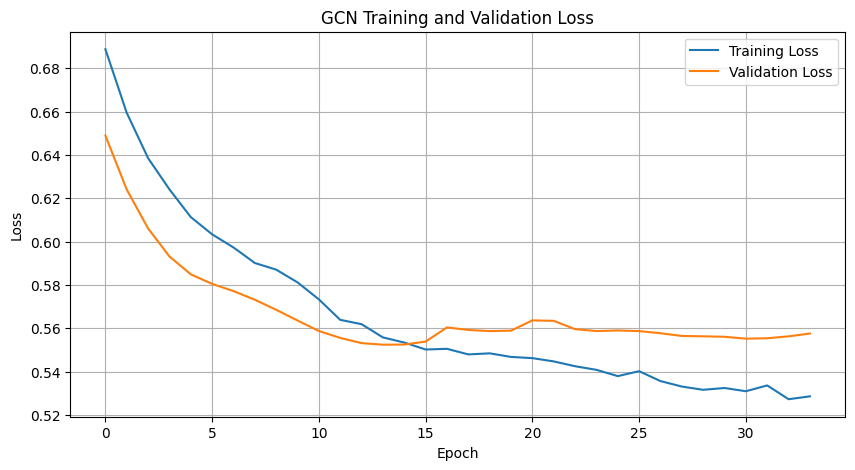

In [17]:
# --- Training curve (sanity check) ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("GCN Training and Validation Loss")
plt.legend(); plt.grid(True)
plt.show()


## Step 7: Flood Probability & Risk Level

Evaluate the model on the held-out test set, then compute a flood probability and risk level for **every** district.

In [18]:
# --- Test set evaluation ---
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probabilities = torch.softmax(logits, dim=1)
    predictions = torch.argmax(logits, dim=1)

y_test = data.y[data.test_mask].cpu().numpy()
pred_test = predictions[data.test_mask].cpu().numpy()
flood_probability_test = probabilities[data.test_mask, 1].cpu().numpy()

print("Test Accuracy:", round(accuracy_score(y_test, pred_test), 4))
print("Test ROC-AUC :", round(roc_auc_score(y_test, flood_probability_test), 4))
print()
print(classification_report(y_test, pred_test, target_names=["No Flood", "Flood"]))


Test Accuracy: 0.6148
Test ROC-AUC : 0.7714

              precision    recall  f1-score   support

    No Flood       0.95      0.54      0.69        96
       Flood       0.34      0.88      0.49        26

    accuracy                           0.61       122
   macro avg       0.64      0.71      0.59       122
weighted avg       0.82      0.61      0.65       122



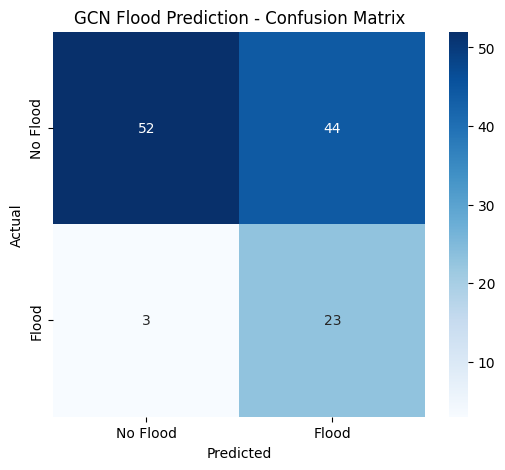

In [19]:
# --- Confusion matrix ---
cm = confusion_matrix(y_test, pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Flood", "Flood"], yticklabels=["No Flood", "Flood"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("GCN Flood Prediction - Confusion Matrix")
plt.show()


### Save the real test metrics

These numbers (not a rounded-up guess) are what should go in your README and
resume bullet. Re-run this cell any time you retrain the model so the saved
file always reflects the current model.

In [20]:
import json

metrics = {
    "test_accuracy": round(accuracy_score(y_test, pred_test), 4),
    "test_roc_auc": round(roc_auc_score(y_test, flood_probability_test), 4),
    "n_test_nodes": int(test_mask.sum()),
    "classification_report": classification_report(
        y_test, pred_test, target_names=["No Flood", "Flood"], output_dict=True
    ),
}

os.makedirs("outputs", exist_ok=True)
with open("outputs/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved outputs/metrics.json")
print(f"Test accuracy: {metrics['test_accuracy']:.1%}  |  Test ROC-AUC: {metrics['test_roc_auc']:.3f}")
print("\nUse these exact numbers in your README / resume bullet -- don't round up.")

Saved outputs/metrics.json
Test accuracy: 61.5%  |  Test ROC-AUC: 0.771

Use these exact numbers in your README / resume bullet -- don't round up.


In [21]:
# --- Flood probability & risk level for every district ---
results_df = node_df.copy()
results_df["Flood_Probability"] = probabilities[:, 1].detach().cpu().numpy()
results_df["Predicted_Flood"] = predictions.detach().cpu().numpy()

def risk_category(p):
    if p < 0.30:
        return "Low"
    elif p < 0.60:
        return "Moderate"
    elif p < 0.80:
        return "High"
    else:
        return "Very High"

results_df["Risk_Level"] = results_df["Flood_Probability"].apply(risk_category)
results_df = results_df.sort_values("Flood_Probability", ascending=False).reset_index(drop=True)

results_df[["District", "Flood_Probability", "Risk_Level"]].head(20)


,District,Flood_Probability,Risk_Level
0,Raichur,0.974085,Very High
1,Davangere,0.973895,Very High
2,Ballari,0.973565,Very High
3,Yadgir,0.972917,Very High
4,Dharwad,0.972847,Very High
5,Gadag,0.972369,Very High
6,Bagalkote,0.972369,Very High
7,Chitradurga,0.971801,Very High
8,Hassan,0.971793,Very High
9,Belagavi,0.971497,Very High


## Step 8: Save `flood_risk_predictions.csv`

This file is what the Streamlit dashboard reads.

In [22]:
os.makedirs("outputs", exist_ok=True)
results_path = "outputs/flood_risk_predictions.csv"
results_df.to_csv(results_path, index=False)

print("Saved:", results_path)
print("Rows:", len(results_df), "| Columns:", len(results_df.columns))


Saved: outputs/flood_risk_predictions.csv
Rows: 812 | Columns: 10


## Limitations & Future Work

Being upfront about these shows engineering maturity -- put a version of this
list in your README too:

- **Graph edges are a co-occurrence proxy, not real geography.** Districts are
  connected only because a news report mentioned them in the same flood event,
  not because of actual river-basin membership, elevation, or drainage
  adjacency. A geography-aware graph would likely improve the model and is the
  most natural next step.
- **District-name cleanup is heuristic, not authoritative.** The fuzzy-merge
  step above catches obvious typos but isn't cross-referenced against an
  official government district gazetteer — a few merges may still need manual
  review (check `merge_examples` above).
- **The "Very High" risk class is small** (61 of 837 districts in the current
  output), so metrics on that class specifically are the least stable part of
  the evaluation — worth flagging rather than glossing over.
- **The dashboard's assistant is retrieval-only, not full RAG.** It does
  semantic search (sentence-transformers + cosine similarity) over a small,
  hand-written set of flood-safety passages and returns the closest match —
  there's no generation step synthesizing an answer from retrieved context.
  Accurate to call it "semantic search," not "RAG," unless a generation step
  is added on top.

## Step 9: Streamlit App

The dashboard lives in its own file, `app.py`, alongside this notebook —
kept separate rather than embedded here so it can be edited and version
controlled independently of the training pipeline. It:

- Reads `outputs/flood_risk_predictions.csv`
- Adds **live rainfall** for the selected district (Open-Meteo API)
- Fuses the GCN probability + live rainfall into a **current risk score**
- Retrieves the closest matching flood-safety guidance via semantic search
  (sentence-transformers) over a small knowledge base

In [23]:
!python -m pip install -q streamlit sentence-transformers requests


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 10: Launch the Dashboard

`streamlit run` starts a long-running server, so run it from a **terminal** (not inside this notebook, since a notebook cell would just hang):

```bash
streamlit run app.py
```

Then open the URL it prints (usually `http://localhost:8501`). Pick a district in the sidebar to see its GCN flood probability, live rainfall, fused current risk score, and retrieved flood-safety guidance.